***Defensive_Midfielder_Recruitment_Report***

In [8]:
!pip install mplsoccer statsbombpy -q

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsbombpy import sb

# Load La Liga 2015/2016 - Messi season, full data available
matches = sb.matches(competition_id=11, season_id=26)
print(f"Total matches: {len(matches)}")
print(matches[['match_id', 'home_team', 'away_team']].head(5))

Total matches: 38
   match_id  home_team    away_team
0    267183  Barcelona  Real Madrid
1    265835  Barcelona      Sevilla
2    266838     Málaga    Barcelona
3    265963  Barcelona       Getafe
4    266117  Barcelona      Granada


/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


In [9]:
# Get defensive actions
pressures = all_events[all_events['type'] == 'Pressure'].copy()
interceptions = all_events[all_events['type'] == 'Interception'].copy()
ball_recoveries = all_events[all_events['type'] == 'Ball Recovery'].copy()

# Group by player
player_defense = pd.concat([pressures, interceptions, ball_recoveries])
player_defense = player_defense.groupby('player').agg(
    defensive_actions=('type', 'count')
).reset_index()

# Combine passing and defensive stats
player_profile = player_passes.merge(player_defense, on='player', how='left')
player_profile['defensive_actions'] = player_profile['defensive_actions'].fillna(0)

# Sort by progressive passes
player_profile = player_profile.sort_values('progressive_passes', ascending=False)

print(player_profile[['player', 'total_passes', 'pass_accuracy',
                        'progressive_passes', 'defensive_actions']].head(15))

                            player  total_passes  pass_accuracy  \
6      Javier Alejandro Mascherano          1786           91.1   
4            Gerard Piqué Bernabéu          1665           90.3   
9   Lionel Andrés Messi Cuccittini          2365           81.9   
2       Claudio Andrés Bravo Muñoz           922           83.2   
8                   Jérémy Mathieu          1563           88.6   
3            Daniel Alves da Silva          2327           85.1   
17        Sergio Busquets i Burgos          2077           92.7   
7                 Jordi Alba Ramos          2139           85.9   
18          Xavier Hernández Creus          1831           90.0   
5                     Ivan Rakitić          1793           87.0   
1             Andrés Iniesta Luján          1370           89.3   
11             Marc Bartra Aregall           734           91.0   
0            Adriano Correia Claro           814           86.9   
13   Neymar da Silva Santos Junior          1599           80.

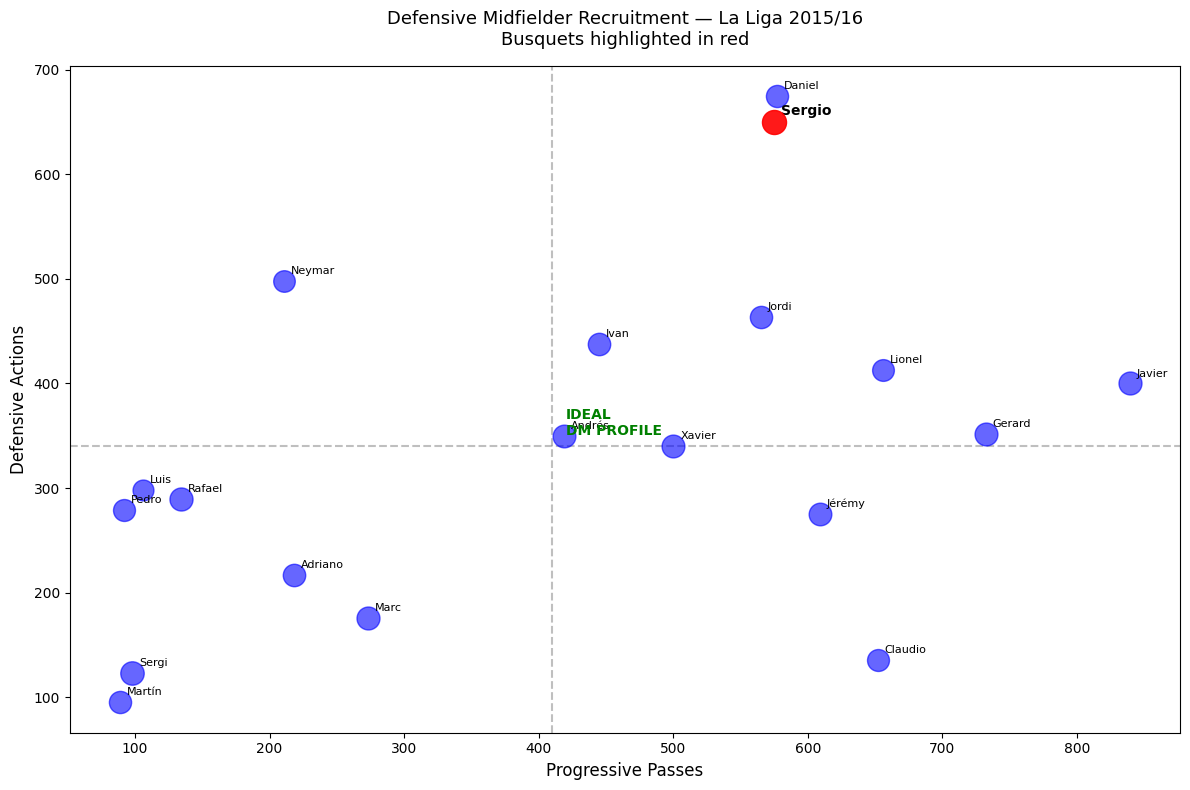

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))

for _, player in player_profile.iterrows():
    is_busquets = 'Busquets' in player['player']
    color = 'red' if is_busquets else 'blue'
    size = 300 if is_busquets else player['pass_accuracy'] * 3
    ax.scatter(player['progressive_passes'], player['defensive_actions'],
               s=size, alpha=0.9 if is_busquets else 0.6,
               color=color, zorder=5 if is_busquets else 3)
    ax.annotate(player['player'].split()[0],
                (player['progressive_passes'], player['defensive_actions']),
                fontsize=8 if not is_busquets else 10,
                fontweight='bold' if is_busquets else 'normal',
                xytext=(5, 5), textcoords='offset points')

avg_prog = player_profile['progressive_passes'].mean()
avg_def = player_profile['defensive_actions'].mean()
ax.axvline(avg_prog, color='gray', linestyle='--', alpha=0.5)
ax.axhline(avg_def, color='gray', linestyle='--', alpha=0.5)

ax.text(avg_prog + 10, avg_def + 10, 'IDEAL\nDM PROFILE',
        fontsize=10, color='green', fontweight='bold')

ax.set_xlabel('Progressive Passes', fontsize=12)
ax.set_ylabel('Defensive Actions', fontsize=12)
ax.set_title('Defensive Midfielder Recruitment — La Liga 2015/16\nBusquets highlighted in red',
             fontsize=13, pad=15)
plt.tight_layout()
plt.show()

The scatter plot shows the relationship between progressive passes and defensive actions for every Barcelona player in La Liga 2015/16. Sergio Busquets stands out as one of the highest in both metrics, confirming that he was not only winning the ball back consistently but also moving it forward effectively. Dani Alves sits just above him on defensive actions which is remarkable for a right back, showing how unique he was in that Barcelona system. Players like Mascherano and Piqué are high on progressive passes but low on defensive actions, confirming they were operating as centre backs rather than midfielders. The data clearly shows that Busquets is the closest profile to a modern defensive midfielder like Rodri or Rice — high defensive output combined with high pass accuracy and consistent progression of the ball.

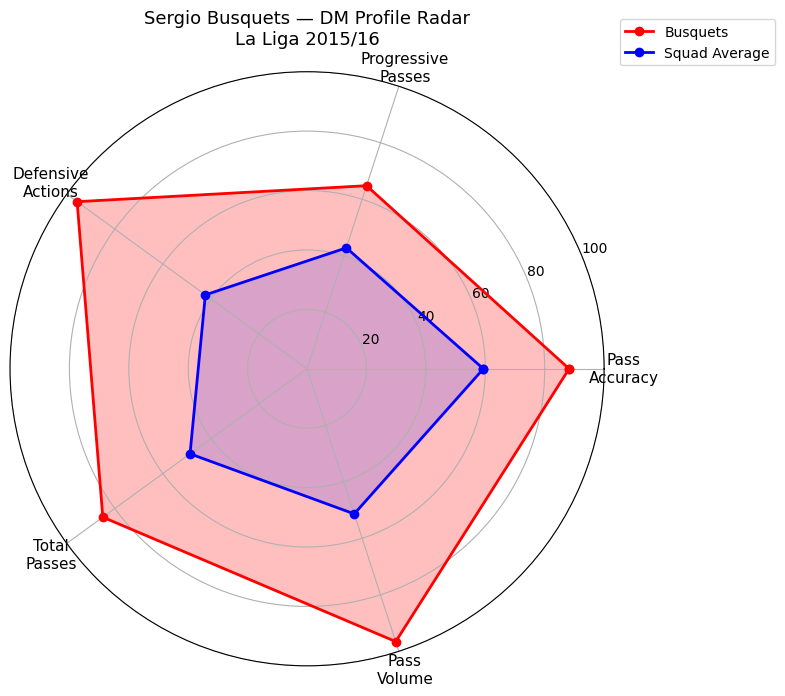

In [12]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Busquets stats normalized to 0-100 scale
categories = ['Pass\nAccuracy', 'Progressive\nPasses', 'Defensive\nActions',
              'Total\nPasses', 'Pass\nVolume']

busquets = player_profile[player_profile['player'].str.contains('Busquets')].iloc[0]
avg = player_profile[['pass_accuracy', 'progressive_passes', 'defensive_actions',
                       'total_passes', 'completed_passes']].mean()

# Normalize each stat to 0-100
def normalize(value, min_val, max_val):
    return (value - min_val) / (max_val - min_val) * 100

values_busquets = [
    normalize(busquets['pass_accuracy'], player_profile['pass_accuracy'].min(), player_profile['pass_accuracy'].max()),
    normalize(busquets['progressive_passes'], player_profile['progressive_passes'].min(), player_profile['progressive_passes'].max()),
    normalize(busquets['defensive_actions'], player_profile['defensive_actions'].min(), player_profile['defensive_actions'].max()),
    normalize(busquets['total_passes'], player_profile['total_passes'].min(), player_profile['total_passes'].max()),
    normalize(busquets['completed_passes'], player_profile['completed_passes'].min(), player_profile['completed_passes'].max()),
]

values_avg = [
    normalize(avg['pass_accuracy'], player_profile['pass_accuracy'].min(), player_profile['pass_accuracy'].max()),
    normalize(avg['progressive_passes'], player_profile['progressive_passes'].min(), player_profile['progressive_passes'].max()),
    normalize(avg['defensive_actions'], player_profile['defensive_actions'].min(), player_profile['defensive_actions'].max()),
    normalize(avg['total_passes'], player_profile['total_passes'].min(), player_profile['total_passes'].max()),
    normalize(avg['completed_passes'], player_profile['completed_passes'].min(), player_profile['completed_passes'].max()),
]

# Draw radar
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values_busquets += values_busquets[:1]
values_avg += values_avg[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, values_busquets, 'o-', linewidth=2, color='red', label='Busquets')
ax.fill(angles, values_busquets, alpha=0.25, color='red')

ax.plot(angles, values_avg, 'o-', linewidth=2, color='blue', label='Squad Average')
ax.fill(angles, values_avg, alpha=0.15, color='blue')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Sergio Busquets — DM Profile Radar\nLa Liga 2015/16',
             fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

The radar chart confirms Busquets as an elite defensive midfielder profile — he registers more than double the squad average in both defensive actions and passing volume, while also leading in pass accuracy. For any club looking to sign a Rodri or Rice type player, this radar shows exactly what to look for — a player who wins the ball back at a high rate and immediately moves it forward with accuracy and consistency. Busquets does both better than anyone else in this squad by a significant margin.